# SCE Hosting Capacity Calculations

**Inputs:**

- `zillow`, full zillow data with imputed units

- `sce`, Southern California Edison Circuit Segments with ICA Capacities

- `sce_cust`, Southern California Edison Customer Table, containing existing generation per circuit

- `sce_territory`, Southern California Edison Territory

- `census`, California census tract boundaries

**Outputs:**

- `sce_census_map`, each California census tract has its corresponding average hosting capacity per household

## Load packages & Data

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
# Load data
# zillow = gpd.read_parquet('~/../../capstone/electrigrid/data/zillow_complete_units.parquet').to_crs(epsg=3310)
zillow = gpd.read_parquet("~/../../capstone/electrigrid/data/final_building.parquet").to_crs(epsg=3310)
sce = gpd.read_parquet("~/../../capstone/electrigrid/data/utilities/sce_circuits/ica_circuit_segments.parquet").to_crs(epsg=3310)
sce_cust = pd.read_csv("~/../../capstone/electrigrid/data/utilities/sce_circuits/ICA_Single_Consolidated_Table.csv")
sce_territory = gpd.read_file("~/../../capstone/electrigrid/data/utilities/sce_circuits/SCE_Service_Territory/SCE_Service_Territory.shp").to_crs(3310)
census = gpd.read_file("~/../../capstone/electrigrid/data/census/tl_2025_06_tract/tl_2025_06_tract.shp").to_crs(3310)

In [3]:
# Add residential percent & existing gen to circuits
sce = sce.merge(sce_cust[['circuit_name', 'res_pct', 'existing_gen']], how='left', on='circuit_name')

## Clean data

In [4]:
# convert columns to numeric
# ica_overall_pv & uniform generation are already numeric
sce['ica_overall_load'] = pd.to_numeric(sce['ica_overall_load'], errors='coerce')
sce['ica_overall_pv_op_flex'] = pd.to_numeric(sce['ica_overall_pv_op_flex'], errors='coerce')
sce['uniform_generation_op_flex'] = pd.to_numeric(sce['uniform_generation_op_flex'], errors='coerce')

In [5]:
# some capacities are na, drop na rows based on columns
na_rows_count = len(sce) - len(sce.dropna(subset=['ica_overall_pv', 'ica_overall_load']))
print(f'Dropped rows: {na_rows_count}')

sce = sce.dropna(subset=['ica_overall_pv', 'ica_overall_load'])

Dropped rows: 25883


In [6]:
# crop zillow to only within sce territory
zillow_sce = gpd.sjoin(zillow, sce_territory[['geometry']], how='inner', predicate='within')[zillow.columns]

## Join buildings to closest segment

In [7]:
linked = gpd.sjoin_nearest(zillow_sce, sce, how='left', distance_col='dist_to_line_m')

In [8]:
# sum housing units per section_id 
units_per_seg = linked.groupby('section_id')['unit'].sum().rename('tothh_seg')
linked = linked.merge(units_per_seg, on='section_id')
# drop observations with no housing units, will avoid divide-by-zero error in per-household capacity calculation
linked = linked[linked['tothh_seg'] > 0]

# sum housing units across all segments in each circuit (tothh_ctot in Brockway Eq. 8)
units_per_circuit = linked.groupby('circuit_name')['unit'].sum().rename('tothh_circuit')
linked = linked.merge(units_per_circuit, on='circuit_name')

In [9]:
linked[['unit', 'GEOID', 'circuit_name', 'section_id', 'ica_overall_pv', 'tothh_seg', 'tothh_circuit']].head()

,unit,GEOID,circuit_name,section_id,ica_overall_pv,tothh_seg,tothh_circuit
0,2.0,06071010426,Sunnyvale,240254355,0.0,1007.0,5725.0
1,2.0,06071010426,Sunnyvale,240254355,0.0,1007.0,5725.0
2,1.0,06071010426,Sunnyvale,240254355,0.0,1007.0,5725.0
3,5.0,06071010425,Sunnyvale,240254355,0.0,1007.0,5725.0
4,6.0,06071010434,Sunnyvale,230124065,0.0,1096.0,5725.0


## Calculate *DER_remain* function

In [10]:
def calc_der_remain(linked, cap_col):
    
    # Part of Brockway Eq. 9: maximum capacity of the whole circuit
    max_cap = linked.groupby('circuit_name')[cap_col].max().rename('DER_max_circuit')
    linked = linked.merge(max_cap, on='circuit_name')

    # Brockway Eq. 8: find household-weighted capacity for each segment so that
    # segments serving more households contribute more to circuit total 
    linked['_hhWt'] = linked[cap_col] * (linked['tothh_seg'] / linked['tothh_circuit'])

    # Part of Brockway Eq. 9: sum of household-weighted capacities across all segments for each circuit
    # must deduplicate first as buildings sharing a segment would cause that segment's _hhWt to be counted multiple times
    summ_hhWt = linked.drop_duplicates('section_id').groupby('circuit_name')['_hhWt'].sum().rename('summ_hhWt')
    linked = linked.merge(summ_hhWt, on='circuit_name')
    
    # Brockway Eq. 9: normalize household-weighted capacity back to circuit maximum
    linked['_hhWt_n'] = linked['_hhWt'] * (linked['DER_max_circuit'] / linked['summ_hhWt'])

    # Brockway Eq. 10: cap normalized capacity at the segment's own capacty
    linked['_hhWt_nadj'] = linked[['_hhWt_n', cap_col]].min(axis=1)
    
    # Brockway Eq. 11: calculate DER_remain per household & convert to kW
    linked[f'DER_remain_{cap_col}_hh'] = (linked['_hhWt_nadj'] / linked['tothh_seg']) * 1000

    # drop intermediate columns for subsequent iterations
    return linked.drop(columns=['DER_max_circuit', '_hhWt', 'summ_hhWt', '_hhWt_n', '_hhWt_nadj'])

Columns to calculate remaining capacity for:

- **PV w/out Op Flex**: `ica_overall_pv`

- **PV w/ Op Flex**: `ica_overall_pv_op_flex`, *raw data has many NAs, would need to drop NA rows but would result in big data loss*.

- **Load**: `ica_overall_load`

In [11]:
# call function on columns
for col in ['ica_overall_pv', 'ica_overall_load']:
    linked = calc_der_remain(linked, col)

In [12]:
# rename columns
linked = linked.rename(columns={
    "DER_remain_ica_overall_pv_hh":"DER_remain_pv_hh",
    "DER_remain_ica_overall_load_hh":"DER_remain_load_hh"
})

# Add existing generation

Existing generation is reported at the circuit level (MW), to add it to the remaining hosting capacity, convert to kW and divide by total households per circuit to get an estimate for existing generation capacity per household.

In [13]:
linked['DER_exist_hh'] = (linked['existing_gen'] * 1000) / linked['tothh_circuit']

In [14]:
linked['DER_total_pv_hh'] = linked['DER_remain_pv_hh'] + linked['DER_exist_hh']

In [15]:
linked[['unit', 'section_id', 'tothh_seg', 'tothh_circuit', 'DER_remain_pv_hh', 'DER_remain_load_hh', 'DER_total_pv_hh']].head()

,unit,section_id,tothh_seg,tothh_circuit,DER_remain_pv_hh,DER_remain_load_hh,DER_total_pv_hh
0,2.0,240254355,1007.0,5725.0,0.0,0.0,0.660786
1,2.0,240254355,1007.0,5725.0,0.0,0.0,0.660786
2,1.0,240254355,1007.0,5725.0,0.0,0.0,0.660786
3,5.0,240254355,1007.0,5725.0,0.0,0.0,0.660786
4,6.0,230124065,1096.0,5725.0,0.0,0.0,0.660786


## Brockway Fig. 2A recreation

In [16]:
thresholds = [0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10]

total_hh = linked['unit'].sum()
summary = pd.DataFrame({
    'threshold': thresholds,
    'tot_pv_prop_access': [linked.loc[linked['DER_total_pv_hh'] >= t, 'unit'].sum() / total_hh for t in thresholds],
    'load_prop_access': [linked.loc[linked['DER_remain_load_hh'] >= t, 'unit'].sum() / total_hh for t in thresholds]
})

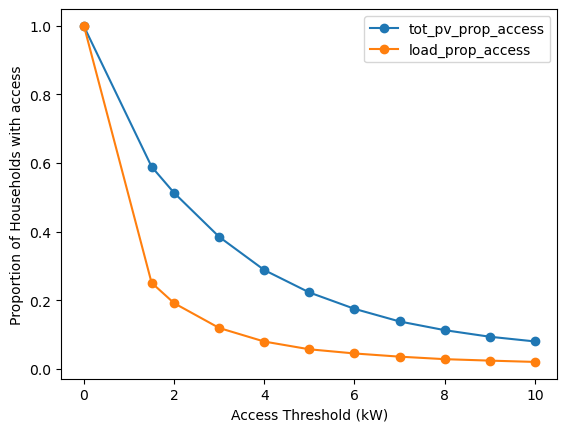

In [17]:
fig, ax = plt.subplots()
summary.plot(ax=ax, x='threshold', marker='o')
ax.set_xlabel('Access Threshold (kW)')
ax.set_ylabel('Proportion of Households with access')
plt.show()

## Census Tract Aggregation

In [18]:
linked = linked.drop(labels=['index_right'], axis=1)

In [19]:
# calculate households per census tract
tract_hh_count = linked.groupby(['GEOID'])['unit'].sum().reset_index(name='zillow_tract_hh_count')

**Consider**: Zillow data is odd.

For example: Tract **06081603801**

- 1305 Zillow observations (in tract) contribute to ~1.6 million units in one tract.

Specific buildings in question: 

 How to handle? I don't think we can consider every case. Cap `zillow_tract_hh_count`?

Since our unit of analysis is households (`unit`), we use a weighted mean by `unit` to find the average capacity per household in one census tract. This so that a 1-unit house and a 30-unit apartment complex get equal weights when contributing to this average.

**Groupby & Weighted average**:

1. Split `linked` by GEOID
2. For each GEOID, compute 3 weighted averages by `unit` column
3. Stack results into one row per tract

In [20]:
# average der_remain to aggregate up to census tract level
census_der = linked.groupby('GEOID').apply(
    lambda x: pd.Series({
        'avg_DER_remain_pv_hh': np.average(x['DER_remain_pv_hh'], weights=x['unit']),
        'avg_DER_remain_load_hh': np.average(x['DER_remain_load_hh'], weights=x['unit']),
        'avg_DER_total_pv_hh': np.average(x['DER_total_pv_hh'], weights=x['unit']),
    }), include_groups=False
).reset_index()

In [34]:
sce_census_map = census.merge(census_der, on='GEOID')
sce_census_map = sce_census_map.merge(tract_hh_count, on='GEOID')
sce_census_map = sce_census_map[['GEOID', 'zillow_tract_hh_count', 'avg_DER_remain_pv_hh', 'avg_DER_remain_load_hh', 'avg_DER_total_pv_hh', 'geometry']]

In [35]:
# output to parquet
sce_census_map.to_parquet('sce_census_map_new.parquet')

**Final Output:** Each census tract (within SCE area) and its respective DER capacities per household.